# Análise e Predição de Câncer de Mama
## Usando Support Vector Machine (SVM)

Este notebook implementa um modelo de Machine Learning para classificar tumores de mama como **benignos** ou **malignos** utilizando o dataset Breast Cancer Wisconsin.

In [2]:
# Bibliotecas para manipulação de dados
import pandas as pd 
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns 

# Bibliotecas de Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 2. Carregamento e Exploração dos Dados

O dataset Breast Cancer Wisconsin contém 569 amostras de tumores com 30 características cada.

## 1. Importação de Bibliotecas

Importando as bibliotecas necessárias para análise de dados, visualização e machine learning.

In [3]:
# Carregando o dataset
cancer = load_breast_cancer()

In [4]:
# Visualizando a estrutura do dataset
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [5]:
# Exibindo as chaves do dataset
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
# Descrição completa do dataset
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [7]:
# Classes alvo: 0 = Maligno, 1 = Benigno
print(cancer['target_names'])

['malignant' 'benign']


In [8]:
# 30 características (features) do dataset
print(cancer['feature_names'])

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [9]:
# Dimensões dos dados: 569 amostras x 30 features
cancer['data'].shape

(569, 30)

### 2.1 Criando DataFrame para Análise

In [10]:
# Criando um DataFrame pandas para facilitar a análise
df_cancer = pd.DataFrame(np.c_[cancer['data'], cancer['target']], 
                         columns=np.append(cancer['feature_names'], ['target']))

In [11]:
# Visualizando o DataFrame
df_cancer

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0


## 3. Análise Exploratória de Dados (EDA)

Visualizando as relações entre as principais características do dataset.

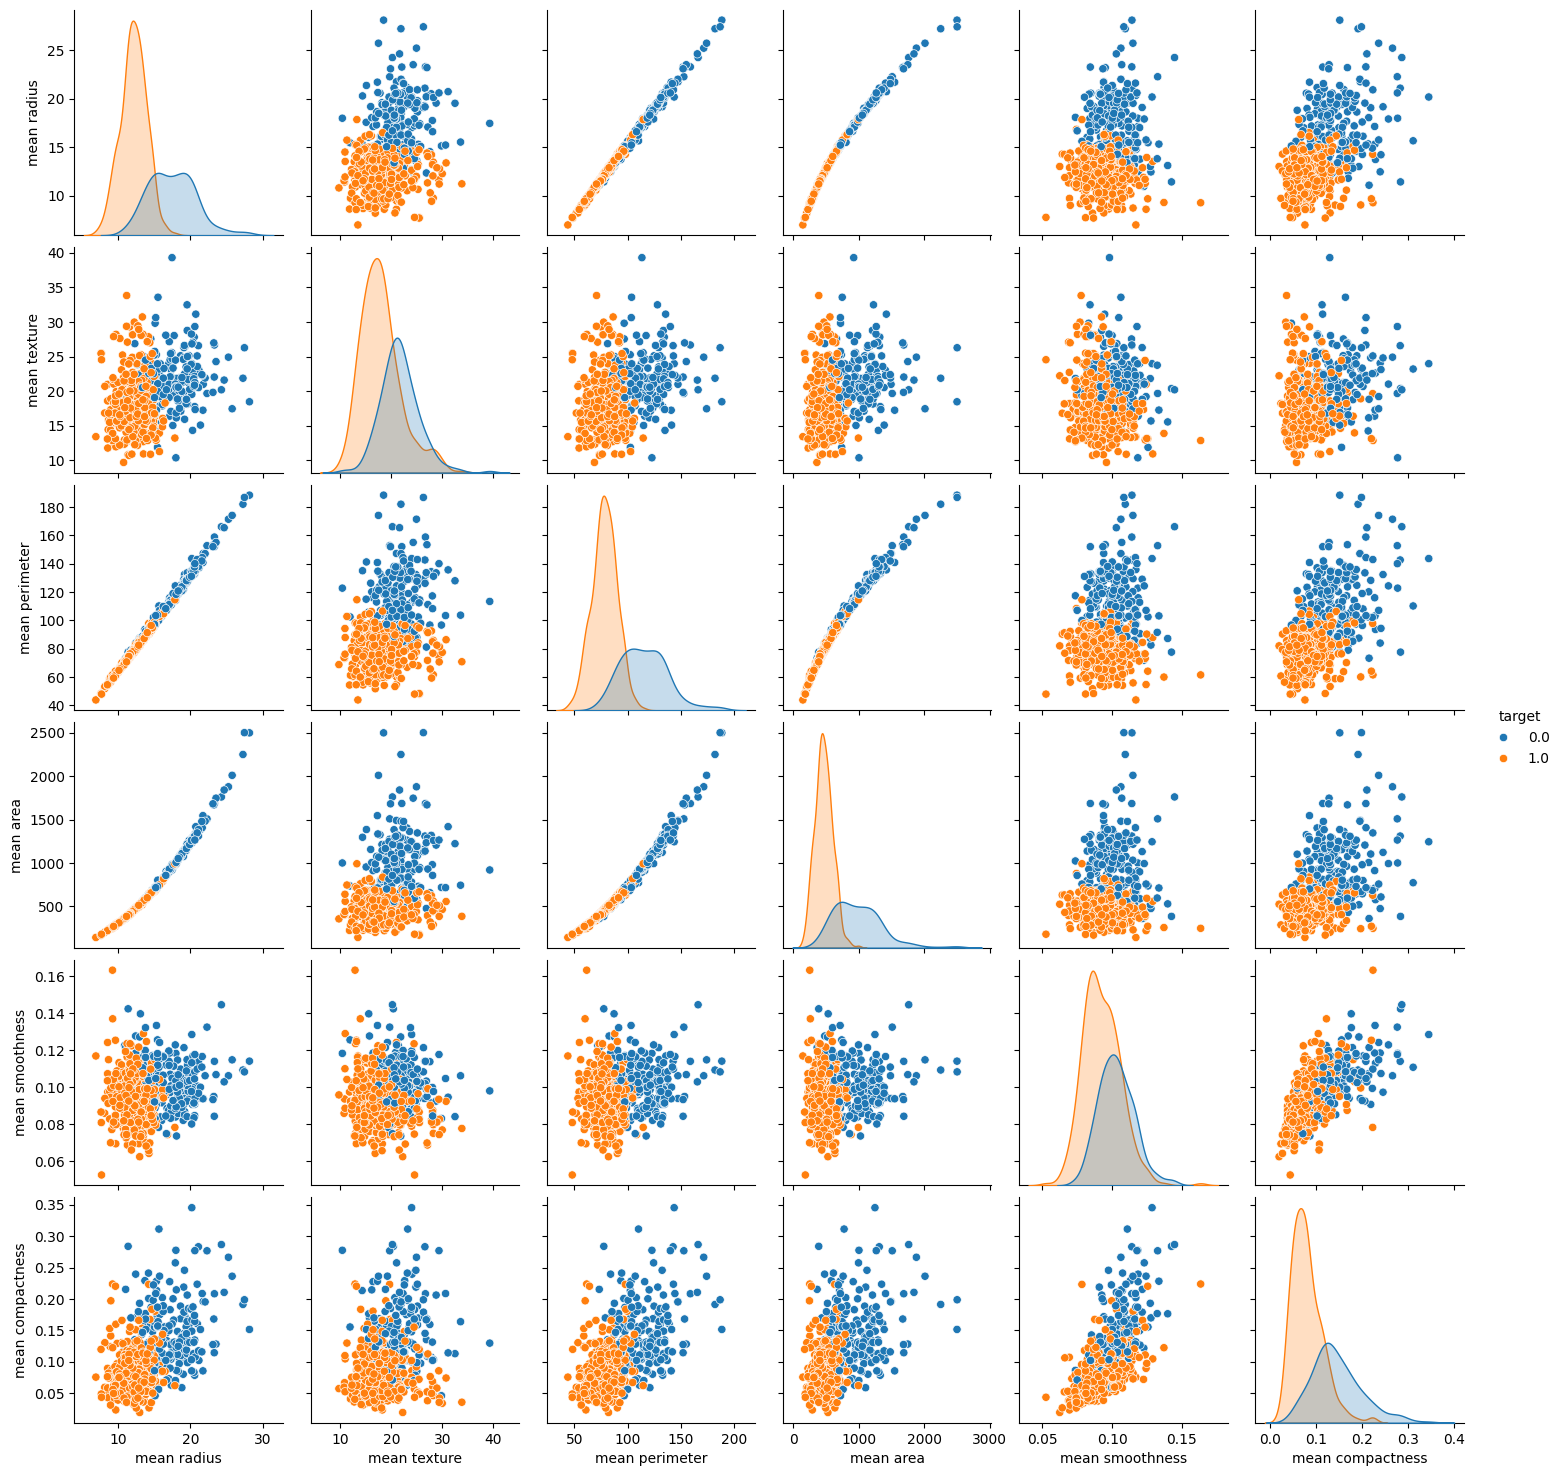

In [12]:
# Pairplot: visualizando relações entre as principais features
sns.pairplot(df_cancer, hue='target', 
             vars=['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness'])

Text(0.5, 0, 'Target (0=Maligno, 1=Benigno)')

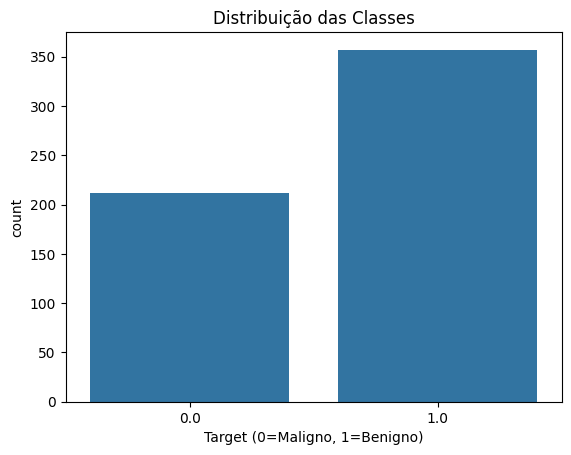

In [13]:
# Distribuição das classes: verificando balanceamento do dataset
sns.countplot(x='target', data=df_cancer)
plt.title('Distribuição das Classes')
plt.xlabel('Target (0=Maligno, 1=Benigno)')

Text(0.5, 1.0, 'Mean Area vs Mean Smoothness')

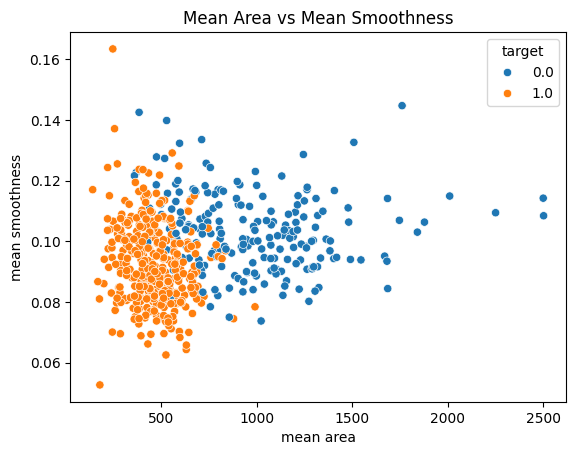

In [14]:
# Scatter plot: relação entre área média e suavidade média
sns.scatterplot(x='mean area', y='mean smoothness', hue='target', data=df_cancer)
plt.title('Mean Area vs Mean Smoothness')

Text(0.5, 1.0, 'Matriz de Correlação das Features')

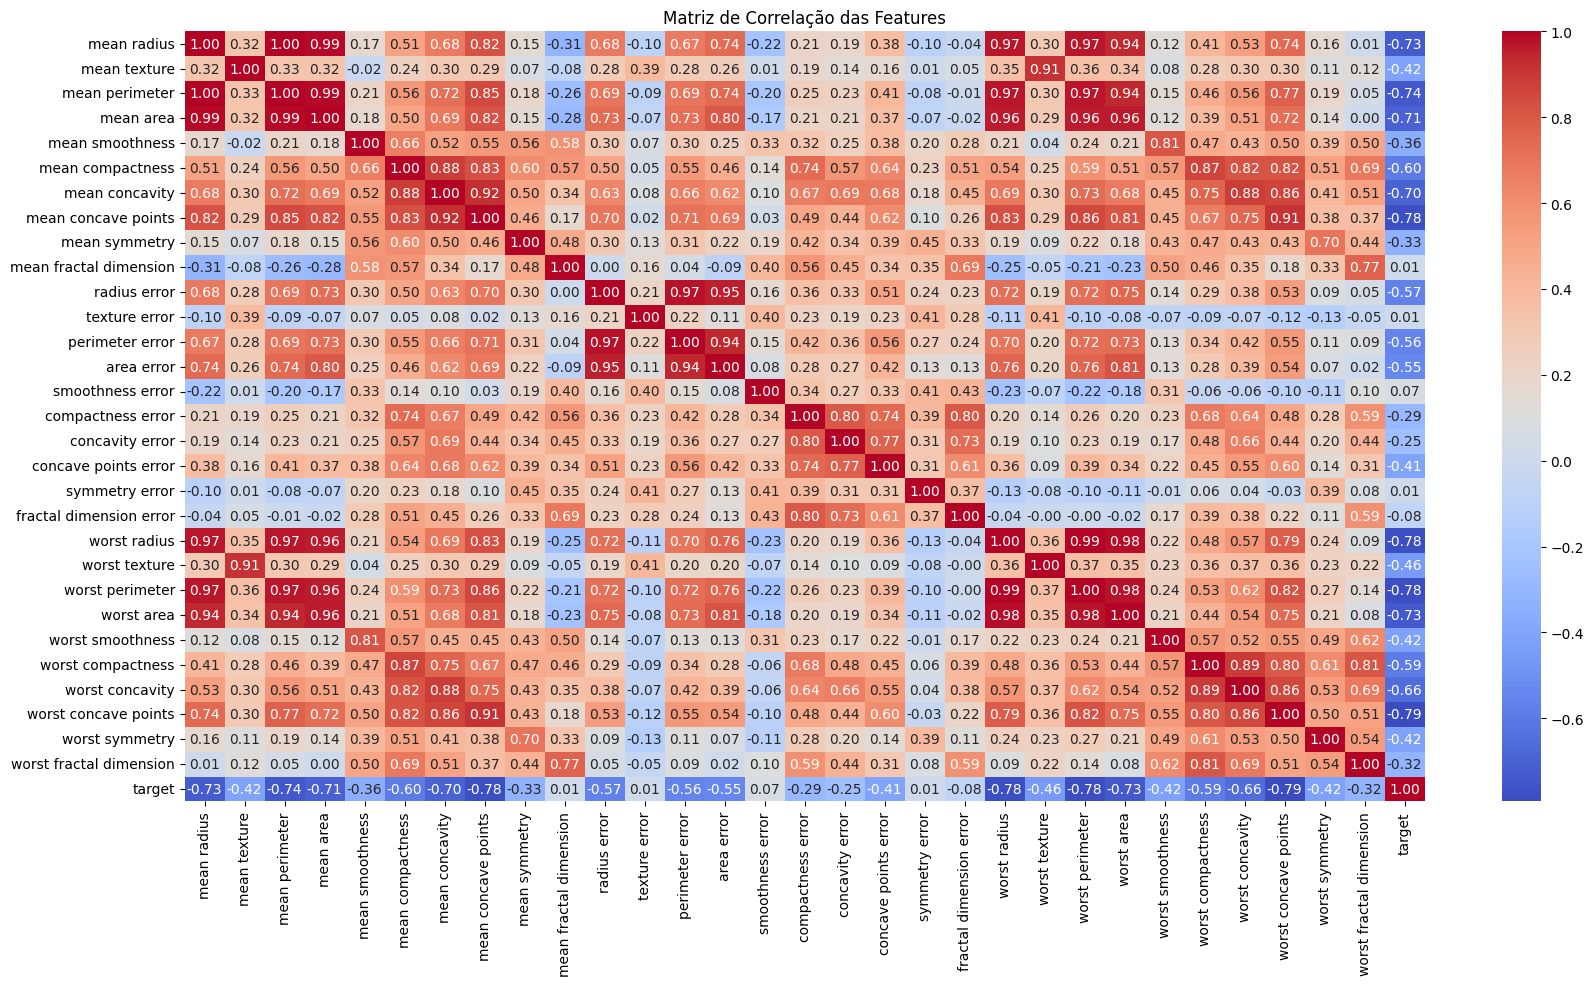

In [15]:
# Mapa de correlação: identificando relações entre features
plt.figure(figsize=(20, 10))
sns.heatmap(df_cancer.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação das Features')

## 4. Preparação dos Dados

Separando features (X) e target (y) para treinamento do modelo.

In [16]:
# Features (X): todas as colunas exceto 'target'
X = df_cancer.drop(['target'], axis=1)

In [17]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [18]:
# Target (y): coluna 'target'
y = df_cancer['target']

### 4.1 Divisão em Conjuntos de Treino e Teste

Dividindo o dataset em 80% treino e 20% teste.

In [19]:
# Split: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

## 5. Modelo Inicial - SVM sem Normalização

Primeiro teste com SVM usando dados não normalizados.

In [20]:
# Criando o modelo SVM
svc_model = SVC()

In [21]:
# Treinando o modelo
svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
# Fazendo predições
Y_predict = svc_model.predict(X_test)
Y_predict

array([0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1.,
       1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0.,
       1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0.])

In [23]:
# Calculando a acurácia do modelo
accuracy_inicial = accuracy_score(y_test, Y_predict)
print(f'Acurácia do Modelo (sem normalização): {accuracy_inicial:.4f} ({accuracy_inicial*100:.2f}%)')

Acurácia do Modelo (sem normalização): 0.9386 (93.86%)


### 5.1 Avaliação do Modelo (sem normalização)

In [24]:
# Matriz de Confusão
cm = confusion_matrix(y_test, Y_predict)

Text(0.5, 23.52222222222222, 'Valor Predito')

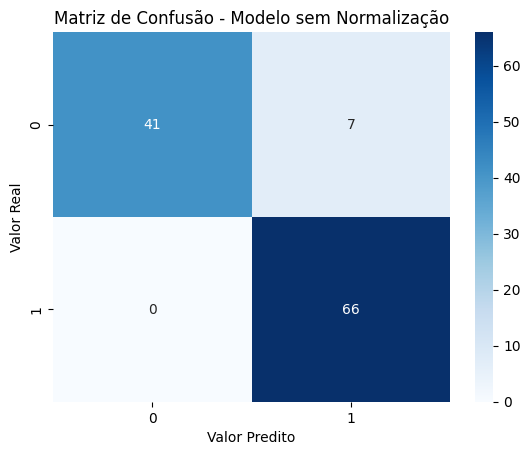

In [25]:
# Visualizando a Matriz de Confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Modelo sem Normalização')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')

## 6. Normalização dos Dados

A normalização é crucial para o SVM, pois coloca todas as features na mesma escala.

In [26]:
# Normalizando dados de treino (Min-Max Scaling)
min_train = X_train.min()
range_train = (X_train - min_train).max()
X_train_scaled = (X_train - min_train) / range_train

### 6.1 Comparação Visual: Antes e Depois da Normalização

Text(0.5, 1.0, 'Dados Originais (Antes da Normalização)')

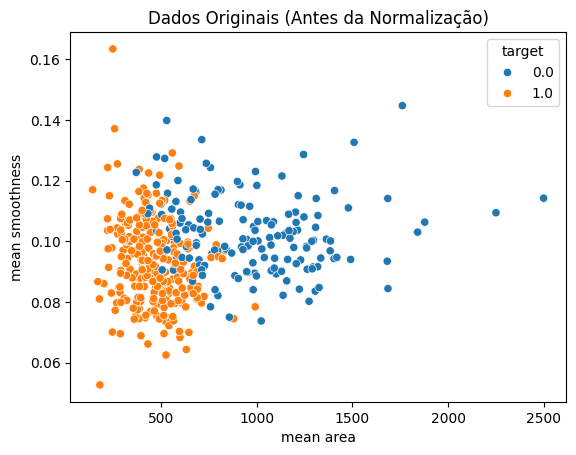

In [27]:
# Dados ANTES da normalização
sns.scatterplot(x=X_train['mean area'], y=X_train['mean smoothness'], hue=y_train)
plt.title('Dados Originais (Antes da Normalização)')

Text(0.5, 1.0, 'Dados Normalizados (Após Normalização)')

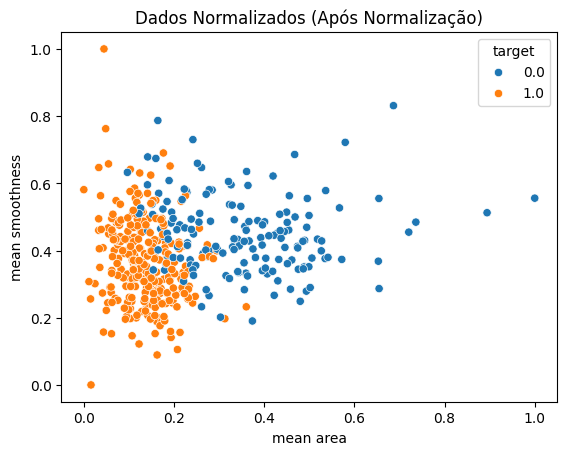

In [28]:
# Dados DEPOIS da normalização
sns.scatterplot(x=X_train_scaled['mean area'], y=X_train_scaled['mean smoothness'], hue=y_train)
plt.title('Dados Normalizados (Após Normalização)')

In [29]:
# Normalizando dados de teste (usando mesmas métricas do treino)
min_test = X_test.min()
range_test = (X_test - min_test).max()
X_test_scaled = (X_test - min_test) / range_test

## 7. Modelo com Dados Normalizados

Treinando o SVM com os dados normalizados para melhor performance.

In [30]:
# Treinando o modelo com dados normalizados
svc_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
# Predições com dados normalizados
y_predict = svc_model.predict(X_test_scaled)

In [32]:
# Calculando a acurácia com normalização
accuracy_normalizado = accuracy_score(y_test, y_predict)
print(f'Acurácia do Modelo (com normalização): {accuracy_normalizado:.4f} ({accuracy_normalizado*100:.2f}%)')
print(f'\nMelhoria: {(accuracy_normalizado - accuracy_inicial)*100:.2f}%')

Acurácia do Modelo (com normalização): 0.9649 (96.49%)

Melhoria: 2.63%


### 7.1 Avaliação do Modelo (com normalização)

In [33]:
# Matriz de Confusão com normalização
cm = confusion_matrix(y_test, y_predict)

Text(0.5, 36.72222222222221, 'Valor Predito')

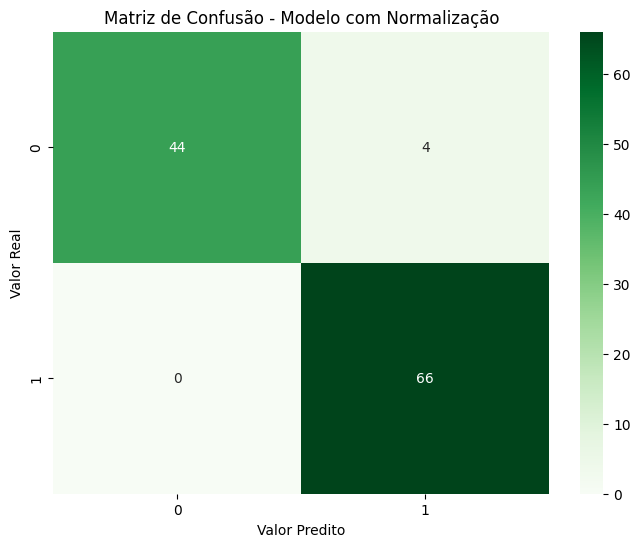

In [34]:
# Visualizando a Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Modelo com Normalização')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')

### 📊 Importância da Matriz de Confusão

A **Matriz de Confusão** é uma ferramenta fundamental para avaliar modelos de classificação:

- **Verdadeiros Positivos (TP)**: Casos benignos corretamente identificados
- **Verdadeiros Negativos (TN)**: Casos malignos corretamente identificados
- **Falsos Positivos (FP)**: Casos malignos classificados como benignos ⚠️ **CRÍTICO**
- **Falsos Negativos (FN)**: Casos benignos classificados como malignos

**Por que é importante?**
1. **Contexto Médico**: Em diagnóstico de câncer, um Falso Negativo (dizer que um tumor maligno é benigno) pode ser fatal
2. **Métricas Derivadas**: Permite calcular Precisão, Recall, F1-Score
3. **Balanceamento**: Mostra se o modelo está enviesado para uma classe
4. **Tomada de Decisão**: Ajuda a decidir se o modelo está pronto para uso clínico

In [35]:
# Relatório de classificação detalhado
print('=== Relatório de Classificação ===\n')
print(classification_report(y_test, y_predict, target_names=['Maligno', 'Benigno']))

=== Relatório de Classificação ===

              precision    recall  f1-score   support

     Maligno       1.00      0.92      0.96        48
     Benigno       0.94      1.00      0.97        66

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 8. Otimização de Hiperparâmetros (Grid Search)

Buscando os melhores parâmetros para o modelo SVM.

In [36]:
# Definindo o grid de parâmetros para testar
param_grid = {
    'C': [0.1, 1, 10, 100],           # Parâmetro de regularização
    'gamma': [1, 0.1, 0.01, 0.001],   # Coeficiente do kernel
    'kernel': ['rbf']                  # Kernel RBF (Radial Basis Function)
}

In [37]:
# Criando o GridSearchCV
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=4, cv=5)

In [38]:
# Treinando com Grid Search (testando todas as combinações)
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.945 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.912 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.956 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.934 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.945 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.901 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.890 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.923 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.868 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.648 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [39]:
# Melhores parâmetros encontrados
print('Melhores Parâmetros:', grid.best_params_)
print('Melhor Score (Cross-Validation):', f'{grid.best_score_:.4f}')

Melhores Parâmetros: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Melhor Score (Cross-Validation): 0.9780


### 8.1 Avaliação do Modelo Otimizado

In [40]:
# Predições com o modelo otimizado
grid_predictions = grid.predict(X_test_scaled)

In [41]:
# Acurácia do modelo otimizado
accuracy_otimizado = accuracy_score(y_test, grid_predictions)
print(f'Acurácia do Modelo Otimizado: {accuracy_otimizado:.4f} ({accuracy_otimizado*100:.2f}%)')

Acurácia do Modelo Otimizado: 0.9649 (96.49%)


In [42]:
# Matriz de Confusão do modelo otimizado
cm = confusion_matrix(y_test, grid_predictions)

Text(0.5, 36.72222222222221, 'Valor Predito')

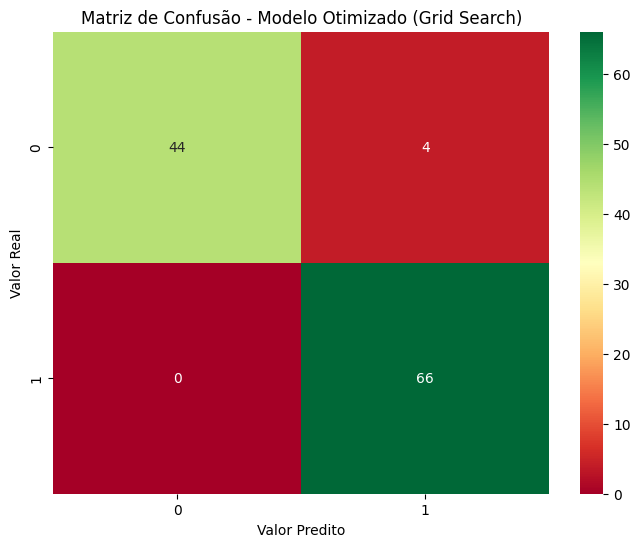

In [43]:
# Visualizando a Matriz de Confusão final
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.title('Matriz de Confusão - Modelo Otimizado (Grid Search)')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')

In [44]:
# Relatório final de classificação
print('=== Relatório de Classificação - Modelo Otimizado ===\n')
print(classification_report(y_test, grid_predictions, target_names=['Maligno', 'Benigno']))

=== Relatório de Classificação - Modelo Otimizado ===

              precision    recall  f1-score   support

     Maligno       1.00      0.92      0.96        48
     Benigno       0.94      1.00      0.97        66

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 9. Comparação Final dos Resultados

Resumo das três abordagens testadas.

C:\Users\vitho\AppData\Local\Temp\ipykernel_26300\1739514075.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Acurácia', data=resultados, palette='viridis')


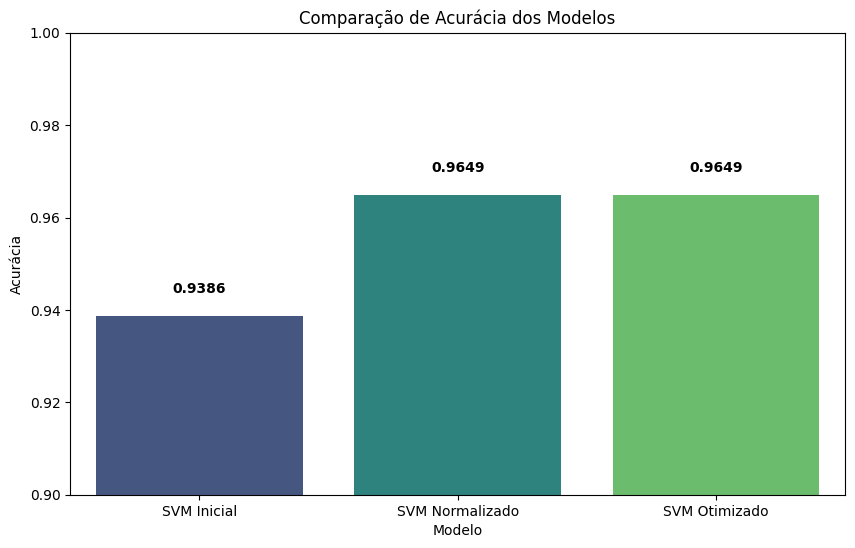


=== RESUMO FINAL ===
         Modelo  Acurácia
    SVM Inicial  0.938596
SVM Normalizado  0.964912
  SVM Otimizado  0.964912


In [45]:
# Comparação visual das acurácias
resultados = pd.DataFrame({
    'Modelo': ['SVM Inicial', 'SVM Normalizado', 'SVM Otimizado'],
    'Acurácia': [accuracy_inicial, accuracy_normalizado, accuracy_otimizado]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Acurácia', data=resultados, palette='viridis')
plt.title('Comparação de Acurácia dos Modelos')
plt.ylabel('Acurácia')
plt.ylim(0.9, 1.0)
for i, v in enumerate(resultados['Acurácia']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

print('\n=== RESUMO FINAL ===')
print(resultados.to_string(index=False))